In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [ ]:
!pip install tensorflow tensorflow-datasets

In [ ]:
dataset, info = tfds.load("cats_vs_dogs", with_info=True, as_supervised=True)

train_data = dataset['train']

print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.X4F7I9_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings 

In [ ]:
IMG_SIZE = 128

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_data = train_data.map(preprocess)

In [ ]:
train_size = int(0.8 * info.splits['train'].num_examples)

train_dataset = train_data.take(train_size)
val_dataset = train_data.skip(train_size)

train_dataset = train_dataset.shuffle(1000).batch(32)
val_dataset = val_dataset.batch(32)

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),

    tf.keras.layers.Dense(1,activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 639s 1s/step - accuracy: 0.6581 - loss: 0.6077 - val_accuracy: 0.7685 - val_loss: 0.4806
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.7769 - loss: 0.4694 - val_accuracy: 0.7780 - val_loss: 0.4794
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 623s 1s/step - accuracy: 0.8140 - loss: 0.4024 - val_accuracy: 0.8156 - val_loss: 0.4141
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 621s 1s/step - accuracy: 0.8493 - loss: 0.3395 - val_accuracy: 0.8135 - val_loss: 0.4077
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 613s 1s/step - accuracy: 0.8798 - loss: 0.2823 - val_accuracy: 0.8201 - val_loss: 0.4036


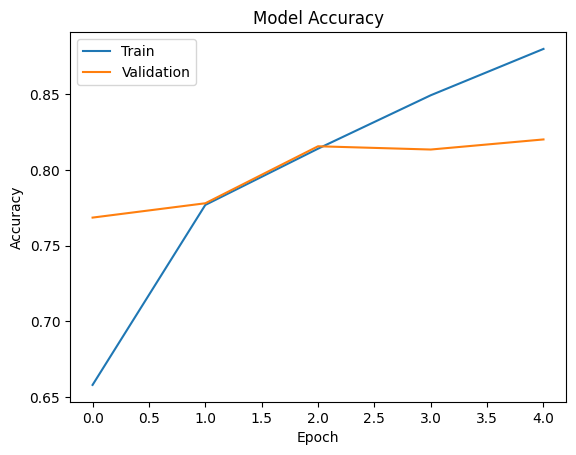

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Photos.jpg to Photos.jpg


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(list(uploaded.keys())[0], target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

NameError: name 'model' is not defined